In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:86% !important;}
div.cell.code_cell.rendered{width:100%;}
div.CodeMirror {font-family:Consolas; font-size:15pt;}
div.output {font-size:15pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:15pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:15px;}
</style>
"""))

In [22]:
#import 
import numpy as np
import seaborn as sns # iris데이터
import pandas as pd #원핫인코딩
from sklearn.preprocessing import LabelEncoder #라벨인코딩(문자 -> 숫자)
from tensorflow.keras.utils import to_categorical #원핫인코딩
from sklearn.model_selection import train_test_split #데이터 분할(층화추출로)
from tensorflow.keras.models import Sequential, load_model, save_model
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import matplotlib.pyplot as plt #학습과정 시각화

- iris데이터
1. sepal_length : 꽃받침길이
2. sepal_width : 꽃받침넓이
3. petal_length : 꽃잎길이
4. petal_width : 꽃잎넓이
5. species : 종(setosa, virginica, versicolor)

In [6]:
#문자변수의 원핫인코딩
iris = sns.load_dataset('iris')
#to_categorical(iris['species'])
labelEncoder = LabelEncoder() #객체 생성
# labelEncoder.fit(iris['species']) #학습
# iris['y'] = labelEncoder.transform(iris['species']) #문자->숫자
iris['y'] = labelEncoder.fit_transform(iris.species)
#iris.iloc[::25]
to_categorical(iris['y'])[::25] #to_categorical의 결과는 numpy배열

array([[1., 0., 0.],
       [1., 0., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 0., 1.],
       [0., 0., 1.]], dtype=float32)

In [10]:
#문자변수 원핫인코딩 방법2
iris = sns.load_dataset('iris')
pd.get_dummies(iris.species).values #pd.get_dummies결과는 데이터프레임
pd.get_dummies(iris.species).to_numpy()[::25] #위와 같음

array([[1, 0, 0],
       [1, 0, 0],
       [0, 1, 0],
       [0, 1, 0],
       [0, 0, 1],
       [0, 0, 1]], dtype=uint8)

In [26]:
# 1. 데이터 생성 및 전처리
iris = sns.load_dataset('iris')
#iris.info() 결측치있으면 결측치처리
#iris['species'].value_counts() 타겟변수의 분포
#독립변수와 타겟변수 분리
iris_X = iris.iloc[:, :-1].to_numpy()
#iris_X[:2]
iris_y = iris.iloc[:,-1]
iris_Y = pd.get_dummies(iris_y).values #원핫인코딩
#iris_Y[::50]
#훈련셋 : 테스트셋 = 8:2
X_train, X_test, Y_train, Y_test = train_test_split(iris_X, iris_Y,
                                                    train_size=0.8, #훈련셋 비율
                                                    #test_size=0.2,#테스트 비율
                                                   stratify=iris_Y, #층화추출
                                                   random_state=7 #랜덤시드값
                                                   )
print(iris_X.shape, iris_Y.shape)
print(X_train.shape, X_test.shape, Y_train.shape, Y_test.shape)

(150, 4) (150, 3)
(120, 4) (30, 4) (120, 3) (30, 3)


In [27]:
#층화추출이 되었는지 확인
#iris_Y.argmax(axis=1) np.argmax(iris_Y, axis=1)와 같음
print(pd.Series(np.argmax(iris_Y, axis=1)).value_counts())
print(pd.Series(np.argmax(Y_train, axis=1)).value_counts())
print(pd.Series(np.argmax(Y_test, axis=1)).value_counts())

0    50
1    50
2    50
dtype: int64
0    40
2    40
1    40
dtype: int64
0    10
2    10
1    10
dtype: int64


In [35]:
# 모델구성(입력4, 출력3)
model = Sequential()
model.add(Dense(units=64, input_dim=4, activation='relu'))
model.add(Dense(units=128, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(units=50, activation='relu'))
model.add(Dropout(0.1))
model.add(Dense(units=30, activation='relu'))
model.add(Dropout(0.1))
model.add(Dense(units=3, activation='softmax')) #출력층
model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_10 (Dense)            (None, 64)                320       
                                                                 
 dense_11 (Dense)            (None, 128)               8320      
                                                                 
 dropout (Dropout)           (None, 128)               0         
                                                                 
 dense_12 (Dense)            (None, 50)                6450      
                                                                 
 dropout_1 (Dropout)         (None, 50)                0         
                                                                 
 dense_13 (Dense)            (None, 30)                1530      
                                                                 
 dropout_2 (Dropout)         (None, 30)               

In [39]:
# 3. 학습과정 설정
model.compile(loss='categorical_crossentropy',
             optimizer='adam',
             metrics=['accuracy'])
# 4. 학습 : epoch마다 val_accuracy값이 좋아지고 있으면 model자동 저장(콜백추가)
# 모델 자동 저장될 경로 : ./model/iris-002-val0.8745.h5
import os
model_save_folder = './model_iris/'
if not os.path.exists(model_save_folder): #폴더가 없으면 폴더 생성
    os.mkdir(model_save_folder)
file = model_save_folder + 'iris-{epoch:03d}-val{val_accuracy:.4f}.h5'
#모델 자동 저장할 콜백 객체
checkpoint = ModelCheckpoint(filepath=file,
                            monitor='val_accuracy', #모니터링 지표(기본값:val_loss)
                            mode='max',
                            save_best_only=True, #기본값:False(매번 저장)
                            verbose=1) #모델 저장 시 로그 출력 (0:로그출력 안함)
#조기종료 콜백 객체
earlyStopping = EarlyStopping(patience=40) #monitor기본값은 val_loss
hist = model.fit(X_train, Y_train,
                #batch_size=40,
                epochs=500,
                validation_split=0.2, #훈련셋의 20%를 검증셋
                callbacks=[earlyStopping, checkpoint])

Epoch 1/500
1/3 [=========>....................] - ETA: 0s - loss: 1.0904 - accuracy: 0.3125
Epoch 1: val_accuracy improved from -inf to 0.70833, saving model to ./model_iris\iris-001-val0.7083.h5
3/3 [==============================] - 1s 89ms/step - loss: 1.0433 - accuracy: 0.4167 - val_loss: 0.9564 - val_accuracy: 0.7083
Epoch 2/500
1/3 [=========>....................] - ETA: 0s - loss: 0.9819 - accuracy: 0.5938
Epoch 2: val_accuracy did not improve from 0.70833
3/3 [==============================] - 0s 16ms/step - loss: 1.0170 - accuracy: 0.5417 - val_loss: 0.8703 - val_accuracy: 0.6667
Epoch 3/500
1/3 [=========>....................] - ETA: 0s - loss: 0.9641 - accuracy: 0.5312
Epoch 3: val_accuracy did not improve from 0.70833
3/3 [==============================] - 0s 19ms/step - loss: 0.9257 - accuracy: 0.5729 - val_loss: 0.8276 - val_accuracy: 0.6667
Epoch 4/500
1/3 [=========>....................] - ETA: 0s - loss: 0.9152 - accuracy: 0.5625
Epoch 4: val_accuracy did not improve 

1/3 [=========>....................] - ETA: 0s - loss: 0.1478 - accuracy: 0.9688
Epoch 30: val_accuracy did not improve from 0.95833
3/3 [==============================] - 0s 18ms/step - loss: 0.1651 - accuracy: 0.9375 - val_loss: 0.1682 - val_accuracy: 0.9583
Epoch 31/500
1/3 [=========>....................] - ETA: 0s - loss: 0.1453 - accuracy: 0.9688
Epoch 31: val_accuracy did not improve from 0.95833
3/3 [==============================] - 0s 16ms/step - loss: 0.1439 - accuracy: 0.9792 - val_loss: 0.1709 - val_accuracy: 0.9583
Epoch 32/500
1/3 [=========>....................] - ETA: 0s - loss: 0.0967 - accuracy: 0.9688
Epoch 32: val_accuracy did not improve from 0.95833
3/3 [==============================] - 0s 16ms/step - loss: 0.1483 - accuracy: 0.9375 - val_loss: 0.1626 - val_accuracy: 0.9583
Epoch 33/500
1/3 [=========>....................] - ETA: 0s - loss: 0.2311 - accuracy: 0.8438
Epoch 33: val_accuracy did not improve from 0.95833
3/3 [==============================] - 0s 17m

Epoch 60/500
1/3 [=========>....................] - ETA: 0s - loss: 0.1895 - accuracy: 0.9375
Epoch 60: val_accuracy did not improve from 0.95833
3/3 [==============================] - 0s 16ms/step - loss: 0.1120 - accuracy: 0.9583 - val_loss: 0.1706 - val_accuracy: 0.9583
Epoch 61/500
1/3 [=========>....................] - ETA: 0s - loss: 0.1291 - accuracy: 0.9375
Epoch 61: val_accuracy did not improve from 0.95833
3/3 [==============================] - 0s 17ms/step - loss: 0.0873 - accuracy: 0.9583 - val_loss: 0.1965 - val_accuracy: 0.9583
Epoch 62/500
1/3 [=========>....................] - ETA: 0s - loss: 0.0850 - accuracy: 0.9688
Epoch 62: val_accuracy did not improve from 0.95833
3/3 [==============================] - 0s 16ms/step - loss: 0.1193 - accuracy: 0.9479 - val_loss: 0.2002 - val_accuracy: 0.9583
Epoch 63/500
1/3 [=========>....................] - ETA: 0s - loss: 0.1274 - accuracy: 0.9688
Epoch 63: val_accuracy did not improve from 0.95833
3/3 [===========================

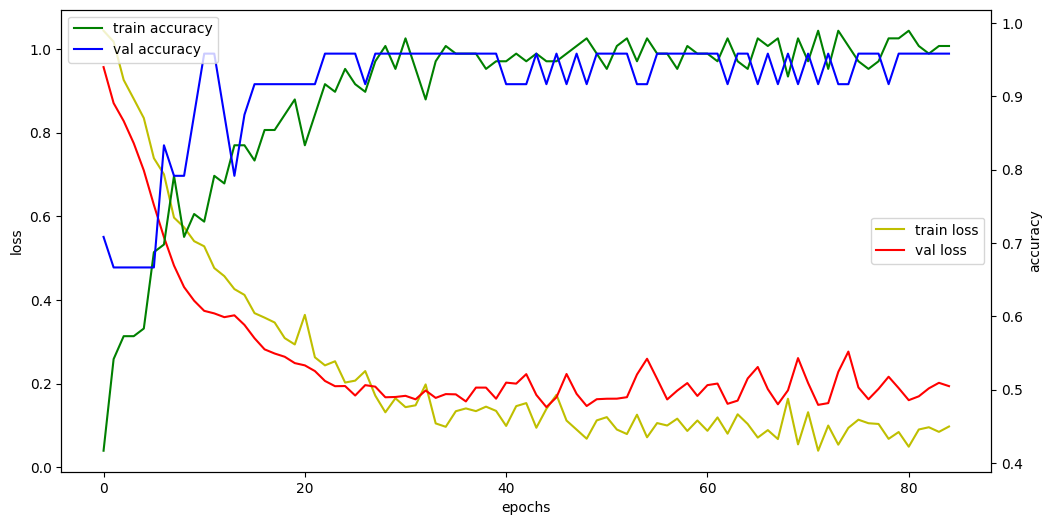

In [41]:
# 5. 모델 학습과정 시각화
fig, loss_ax = plt.subplots(figsize=(12,6))
loss_ax.plot(hist.history['loss'], 'y', label='train loss')
loss_ax.plot(hist.history['val_loss'], 'r', label='val loss')
acc_ax = loss_ax.twinx()
acc_ax.plot(hist.history['accuracy'], 'g', label='train accuracy')
acc_ax.plot(hist.history['val_accuracy'], 'b', label='val accuracy')
loss_ax.set_xlabel('epochs')
loss_ax.set_ylabel('loss')
acc_ax.set_ylabel('accuracy')
loss_ax.legend(loc='center right')
acc_ax.legend(loc='upper left')
plt.show()

In [61]:
# 6. 모델 평가(evalute, 교차)
# iris-001-val0.7083.h5 모델도 같이 평가
from sklearn.metrics import confusion_matrix
from sklearn.metrics import recall_score, precision_score, f1_score
#학습된 모델
loss, acc = model.evaluate(X_test, Y_test)
loss, acc
# 학습완료된 모델의 recall과 prevision을 위해서 실제값과 예측값
real = np.argmax(Y_test, axis=1)
pred = np.argmax(model.predict(X_test, verbose=0) , axis=1)
recall = recall_score(real, pred, average='weighted') # average='weighted':다중분류
precision = precision_score(real, pred, average='weighted')
f1 = f1_score(real, pred, average='weighted')
print('model loss :', loss)
print('model accuracy :', acc)
print('model recall :', recall)
print('model prevision :', precision)
print('model f1 score :', f1)
# 저장됨 모델의 평가
# model2 = load_model('model_iris/iris-001-val0.7083.h5')
# loss, acc = model2.evaluate(X_test,Y_test)
# pred = model2.predict(X_test).argmax(axis=1)
# recall = recall_score(real, pred, average='weighted')
# precision = precision_score(real, pred, average='weighted')
# f1 = f1_score(real, pred, average='weighted')
# print('model2 loss :', loss)
# print('model2 acc:', acc)
# print('model2 recall :', recall)
# print('model2 prevision :', precision)
# print('model2 f1 score :', f1)

1/1 [==============================] - 0s 23ms/step - loss: 0.0103 - accuracy: 1.0000
model loss : 0.010268227197229862
model accuracy : 1.0
model recall : 1.0
model prevision : 1.0
model f1 score : 1.0


In [59]:
#교차표
pred = np.argmax(model.predict(X_test, verbose=0) , axis=1)
pd.crosstab(real, pred, 
           rownames=['real'], colnames=['pred'])

pred,0,1,2
real,,,
0,10,0,0
1,0,10,0
2,0,0,10


In [62]:
confusion_matrix(real, pred)

array([[10,  0,  0],
       [ 0, 10,  0],
       [ 0,  0, 10]], dtype=int64)

In [63]:
# 모델 저장 및 사용
save_model(model, 'model/iris.h5')
model.save('model/iris.h5') #tensorflow 2.18이상일 경우 확장자를 .keras로도 사용가능

In [65]:
# 모델 예측하기
# iris.loc[100] (6.3, 3.3, 3.0, 2.5) 예측하기
result = model.predict([[6.3, 3.3, 3.0, 2.5]])
np.argmax(result)#virginica로 예측

1/1 [==============================] - 0s 38ms/step


1